## <b>Exploratory Data Analysis</b>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### <b> 1. Load and basic shape </b>

In [15]:
df = pd.read_csv("E:\\AIS bsc\\predictive-maintenance\\data\\raw\\AI4I_2020_Predictive_Maintenance_Dataset_(UCI).csv")
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [17]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


<hr>

### <b>2.Missing Values</b>

In [18]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

<hr>

### <b>3. Target Variable Class imbalance</b>

In [19]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [20]:
df["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

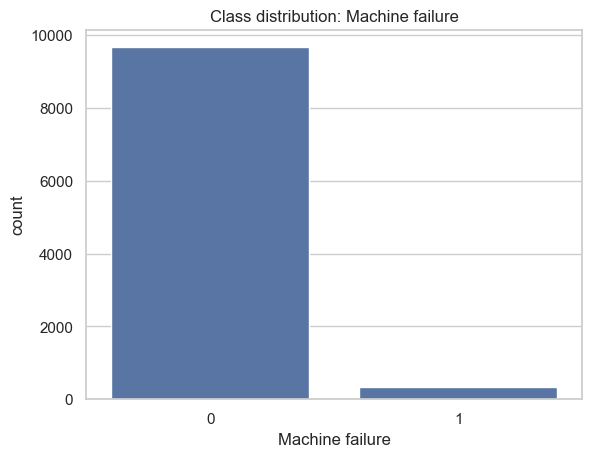

In [21]:
sns.countplot(data=df, x="Machine failure")
plt.title("Class distribution: Machine failure")
plt.show()

A Machine failure happens only about 3.4% of the time.

<hr>

### <b>4. Failure mode breakdown</b>

There are separate flags for why a machine failed (TWF, HDF, PWF, OSF, RNF). We check how they relate to the main label:

Renaming field names for better understanding

In [23]:
df = df.rename(columns={
    "TWF": "Tool wear failure (TWF)",
    "HDF": "Heat dissipation failure (HDF)",
    "PWF": "Power failure (PWF)",
    "OSF": "Overstrain failure (OSF)",
    "RNF": "Random failures (RNF)"
})

df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'Tool wear failure (TWF)',
 'Heat dissipation failure (HDF)',
 'Power failure (PWF)',
 'Overstrain failure (OSF)',
 'Random failures (RNF)']

Failure mode breakdown : AI4I 2020 has separate flags for why a machine failed (TWF, HDF, PWF, OSF, RNF). Worth checking how they relate to the main label:

<b>This just counts how many rows have each specific failure mode flagged as 1. It tells you which failure types are common vs rare in the dataset</b>

In [24]:
failure_modes = [
    "Tool wear failure (TWF)",
    "Heat dissipation failure (HDF)",
    "Power failure (PWF)",
    "Overstrain failure (OSF)",
    "Random failures (RNF)"
]

df[failure_modes].sum()

Tool wear failure (TWF)            46
Heat dissipation failure (HDF)    115
Power failure (PWF)                95
Overstrain failure (OSF)           98
Random failures (RNF)              19
dtype: int64

<i> It's clear that Heat dissipation failure (HDF) is the most common type of failure. </i>

Every row where Machine failure = 1 should have at least one failure-mode flag set, and every row where Machine failure = 0 should have none.

In [25]:
# sanity check: does Machine failure == 1 whenever any failure mode is 1?
df["any_failure_mode"] = df[failure_modes].sum(axis=1) > 0
pd.crosstab(df["Machine failure"], df["any_failure_mode"])

any_failure_mode,False,True
Machine failure,,
0,9643,18
1,9,330


The crosstab shows the label is mostly but not perfectly consistent with the failure-mode flags:

    18 rows have a failure mode flagged but Machine failure = 0
    9 rows have Machine failure = 1 with no failure mode flagged
    
This affects only 27 out of 10,000 rows (~0.27%) and is treated as a minor data quality
quirk rather than a labeling error , Machine failure remains the target variable, and
the five mode flags are dropped before modeling regardless, since they'd leak the label.

#### <b>5. Product type breakdown</b>

In [26]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

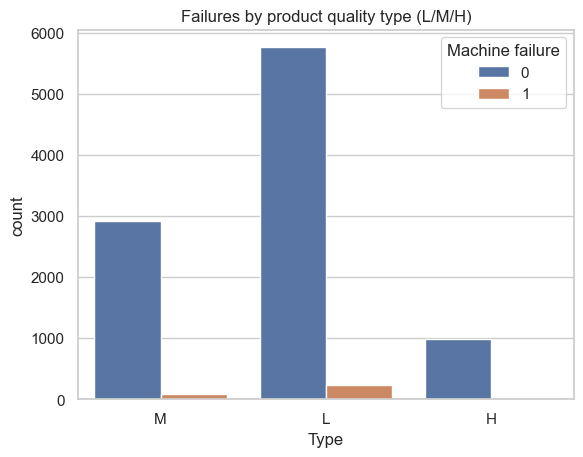

In [27]:
sns.countplot(data=df, x="Type", hue="Machine failure")
plt.title("Failures by product quality type (L/M/H)")
plt.show()

In [51]:
df.groupby("Type")["Machine failure"].agg(["sum", "count", "mean"]).rename(
    columns={"sum": "failures", "count": "total", "mean": "failure_rate_percent"}
).assign(failure_rate_percent=lambda x: (x["failure_rate_percent"] * 100).round(2))

,failures,total,failure_rate_percent
Type,,,
H,21,1003,2.09
L,235,6000,3.92
M,83,2997,2.77


3.92 % of Type L machines fail.  Type L machines have the highest failure rates.

    Type L (low-quality tier) machines fail more often than M/H , consistent with lower-spec components being more failure-prone.

### <b>6. Sensor distributions</b>

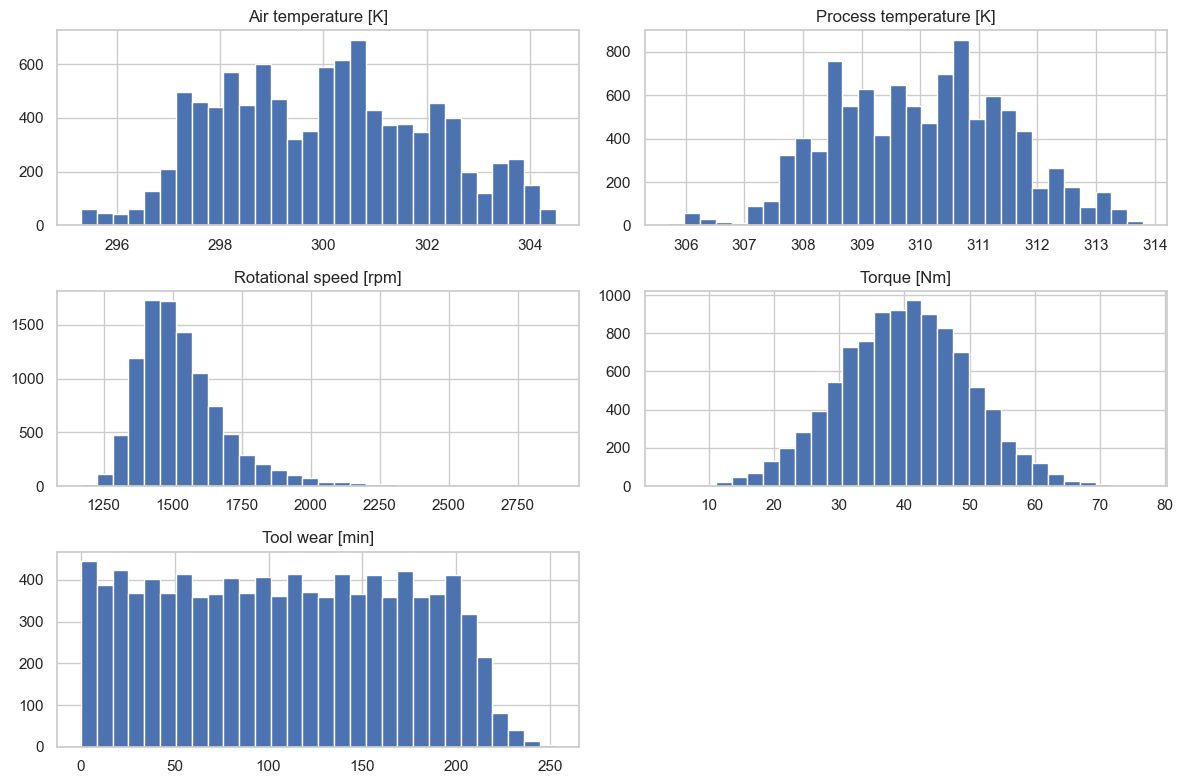

In [52]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[sensor_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

#### <b>7. Sensor distributions split by failure</b>

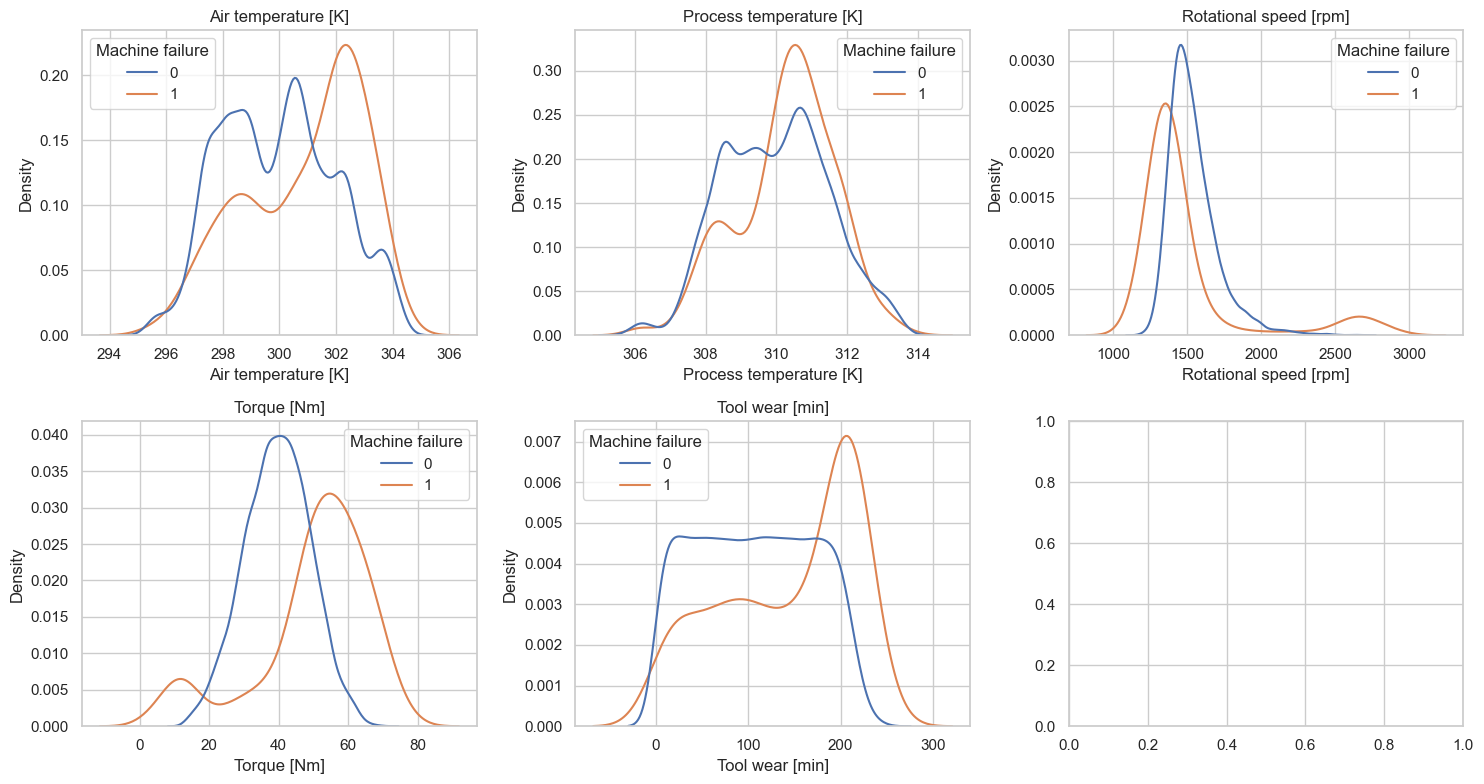

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.kdeplot(data=df, x=col, hue="Machine failure", ax=axes[i], common_norm=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Since the graphs overlap in certain regions it's hard to confirm that a single sensor value can confirm if the machine fails or not.

### <b>8. Correlation Matrix</b>

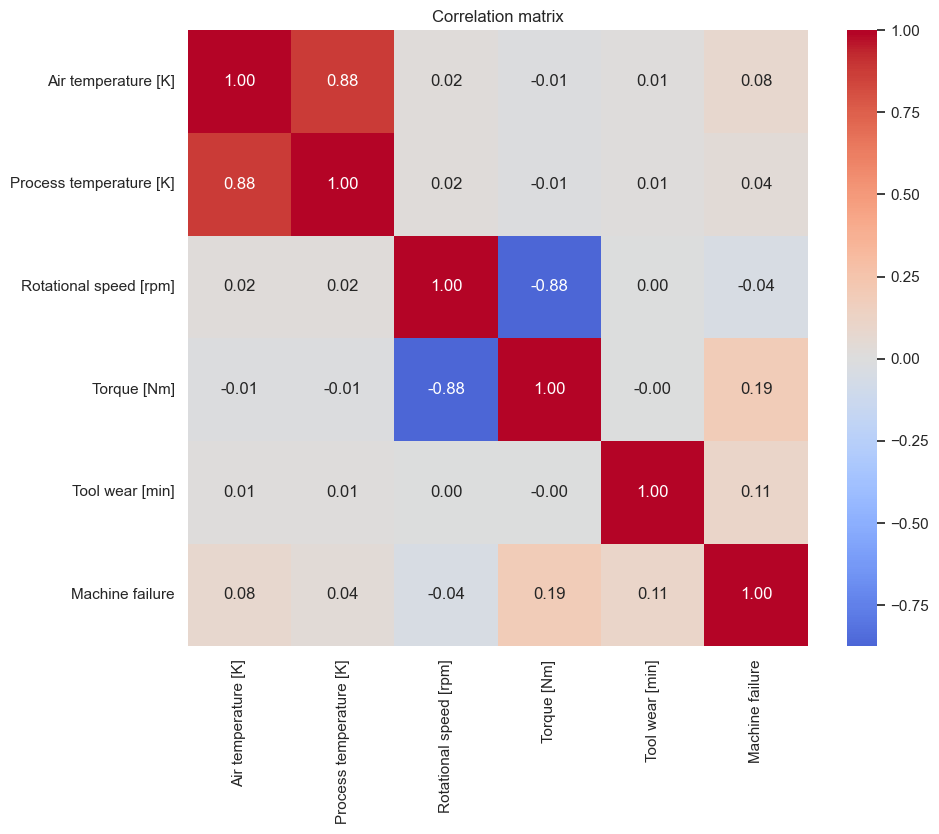

In [54]:
plt.figure(figsize=(10, 8))
corr = df[sensor_cols + ["Machine failure"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

    Correlation only captures linear relationships — a low correlation with Machine failure doesn't mean a sensor is useless for a non-linear model like Random Forest.

#### <b> 9. Torque vs rotational speed (known physical relationship)</b>

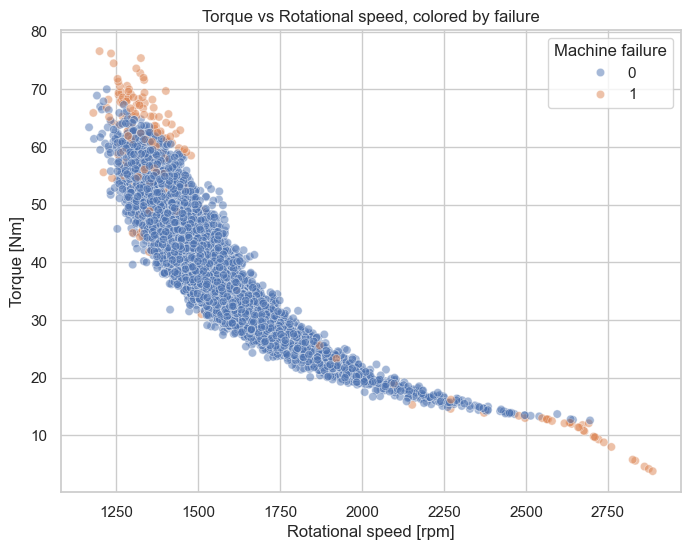

In [55]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Rotational speed [rpm]", y="Torque [Nm]", hue="Machine failure", alpha=0.5)
plt.title("Torque vs Rotational speed, colored by failure")
plt.show()

    The scatter confirms the expected inverse relationship between torque and rotational speed as speed increases, torque decreases, forming a clear curve. Failures (orange points) are noticeably concentrated in the high-torque, low-speed region of the curve, suggesting that machines operating at low speed under high mechanical load are more prone to failure. This is consistent with the overstrain failure mode (OSF) identified in Phase 4, which is physically driven by excessive torque relative to speed.

#### <b>10. Tool wear vs Failure</b>

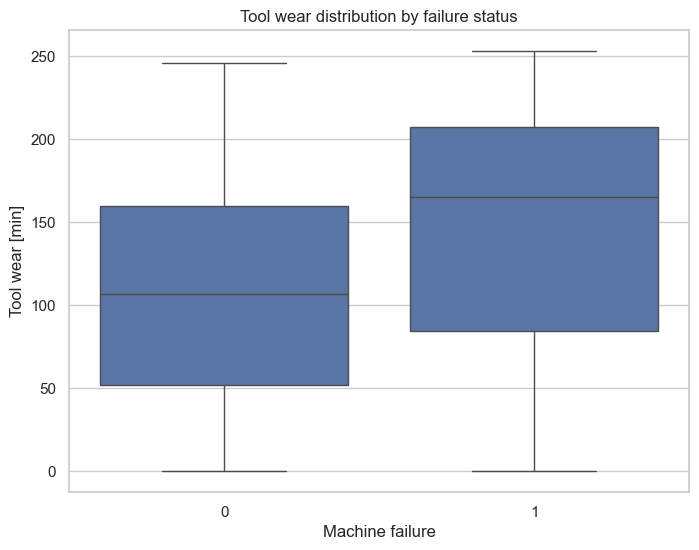

In [56]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Machine failure", y="Tool wear [min]")
plt.title("Tool wear distribution by failure status")
plt.show()

Among the Machines that failed , the Tool wear falls on a higher range from around 80-210. While for the machines that did not fail , Tool wear ranges between 50-160 (approximately.) The ranges overlap so Tool wear alone cannot confirm Machine failure , but the difference between the 2 ranges suggest that Tool wear is strongly linked to Machine Failure.